# **Regime-Aware Stock Forecasting with Stationarity, ACF/PACF & Model Decay Detection**

---

# 🎯 Problem Statement

Financial time series (like stock prices) are **non-stationary, noisy, and regime-dependent**. Traditional models often fail because:

* Statistical properties change over time (**non-stationarity**)
* Market behavior shifts (**regime changes**)
* Model performance degrades (**model decay**)

👉 Objective:

> Build a **robust forecasting system** that:

* Transforms data into stationary form
* Detects **market regimes**
* Uses **ACF/PACF** for model design
* Tracks **model decay**
* Implements **rolling retraining**

---

# 📦 Dataset

We’ll use **Apple stock data** via **Apple Inc. (AAPL)**.

---

# 🧱 Project Flow

1. Data Collection & Setup
2. Stationarity Analysis
3. ACF / PACF Analysis
4. Regime Change Detection
5. Rolling Statistics
6. Model Building (ARIMA)
7. Model Decay Detection
8. Rolling Retraining System

---

# ⚙️ 1. Setup & Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import yfinance as yf

In [2]:
df = yf.download('AAPL', start='2010-01-01')

/tmp/ipykernel_183/488426676.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600
2010-01-05,6.423470,6.459725,6.389611,6.430062,601904800
2010-01-06,6.321295,6.448938,6.314703,6.423469,552160000
2010-01-07,6.309609,6.352157,6.263766,6.344667,477131200
2010-01-08,6.351557,6.352157,6.264066,6.301219,447610800


In [4]:
df = df[['Close']].dropna()

In [5]:
df.shape

(4080, 1)

In [6]:
df.describe()

Price,Close
Ticker,AAPL
count,4080.000000
mean,79.957423
std,77.453020
min,5.754395
25%,18.410466
50%,39.660568
75%,145.250114
max,285.922455


In [7]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0


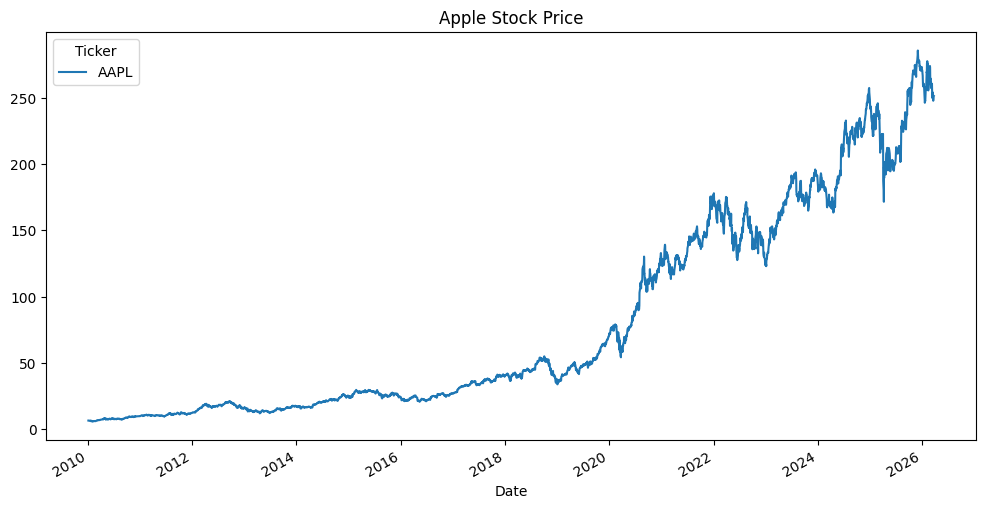

In [8]:
df['Close'].plot(figsize=(12, 6))
plt.title('Apple Stock Price')
plt.show()

---

# 📊 2. Stationarity vs Non-Stationarity

## 🔹 Concept

### Stationary:

* Mean = constant
* Variance = constant
* No trend

### Non-Stationary:

* Trend present
* Changing variance
* Time-dependent structure

---

## 🔍 Visualization

---

## 🧪 ADF Test


In [23]:
def adf_test(series):
  result = adfuller(series)
  print('ADF Statistic: %f' % result[0])
  if result[1] <= 0.05:
    print('p-value: %.4f. Data has no unit root and is stationary' % result[1])
  else:
    print('p-value: %.4f. Data has a unit root and is non-stationary'% result[1])

In [10]:
adf_test(df['Close'])

ADF Statistic: 0.713044
p-value: 0.9901. Data has a unit root and is non-stationary



👉 If **p-value > 0.05 → Non-stationary**

---

## 🔄 Make Data Stationary


In [12]:
df['Returns'] = df['Close'].pct_change()

In [13]:
df.dropna(inplace = True)

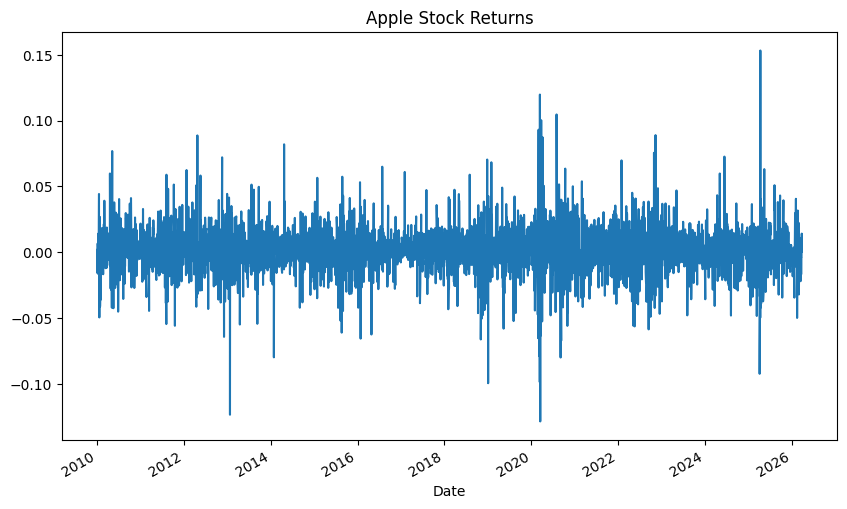

In [14]:
df['Returns'].plot(figsize=(10, 6))
plt.title('Apple Stock Returns')
plt.show()

In [24]:
adf_test(df['Returns'])

ADF Statistic: -21.730227
p-value: 0.0000. Data has no unit root and is stationary


---

# 📉 3. ACF / PACF

## 🔹 Concept

### ACF (AutoCorrelation Function)

* Measures correlation with lagged values

### PACF (Partial ACF)

* Removes indirect correlations

---

## 📊 Plot

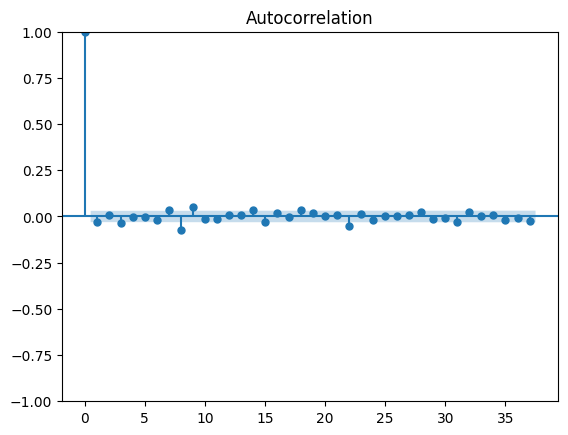

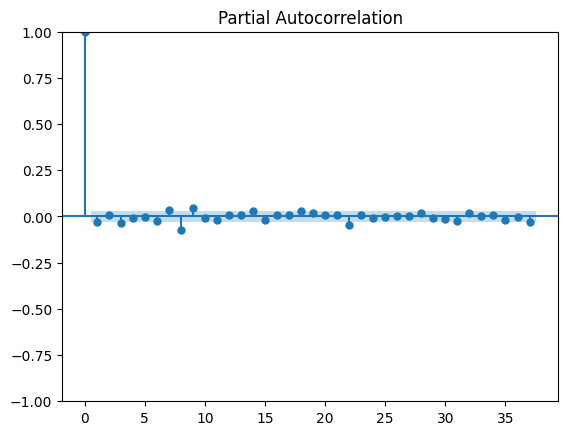

In [21]:
plot_acf(df['Returns'])
plot_pacf(df['Returns'])
plt.show()

---

## 🎯 Interpretation

* ACF cutoff → MA(q)
* PACF cutoff → AR(p)

---

# 🔄 4. Regime Changes

## 🔹 Concept

Markets behave differently in:

* Bull phase 📈
* Bear phase 📉
* Sideways 🟰

---

## 🧠 Detect Using Rolling Mean & Volatility

In [18]:
df['Rolling_Mean'] = df['Returns'].rolling(window=20).mean()

In [19]:
df['Rolling_Volatility'] = df['Returns'].rolling(window=20).std()

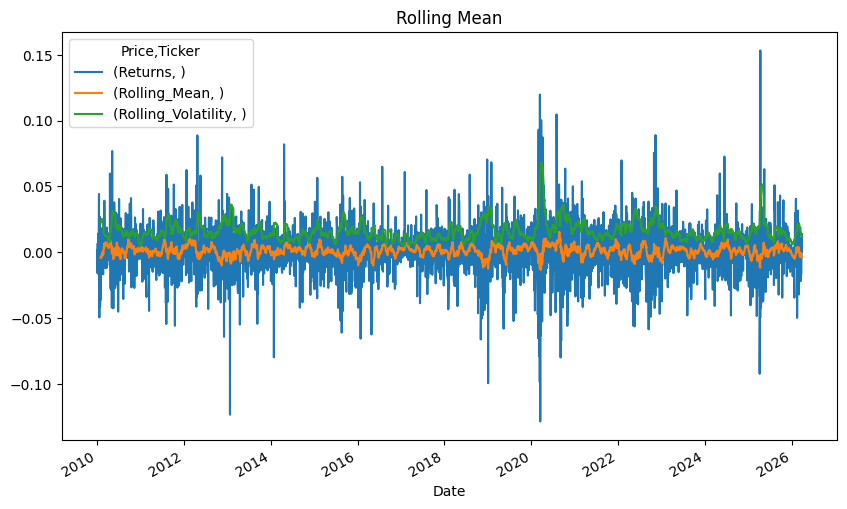

In [20]:
df[['Returns','Rolling_Mean', 'Rolling_Volatility']].plot(figsize=(10, 6))
plt.title('Rolling Mean')
plt.show()

---

## 🔍 Simple Regime Classification

In [25]:
df.head()

Price,Close,Returns,Rolling_Mean,Rolling_Volatility
Ticker,AAPL,,,
Date,,,,
2010-01-05,6.423470,0.001729,NaN,NaN
2010-01-06,6.321295,-0.015906,NaN,NaN
2010-01-07,6.309609,-0.001849,NaN,NaN
2010-01-08,6.351557,0.006648,NaN,NaN
2010-01-11,6.295528,-0.008821,NaN,NaN


In [26]:
def regime_classification(Rolling_Volatility):
  if Rolling_Volatility > df['Rolling_Volatility'].quantile(0.75):
    return 'High Volatility'
  elif Rolling_Volatility < df['Rolling_Volatility'].quantile(0.25):
    return 'Low Volatility'
  else:
    return 'Moderate Volatility'


In [27]:
df['regime'] = df['Rolling_Volatility'].apply(regime_classification)


In [28]:
df['regime']

,regime
Date,
2010-01-05,Moderate Volatility
2010-01-06,Moderate Volatility
2010-01-07,Moderate Volatility
2010-01-08,Moderate Volatility
2010-01-11,Moderate Volatility
...,...
2026-03-18,Moderate Volatility
2026-03-19,Moderate Volatility
2026-03-20,Moderate Volatility



---

# 📊 5. Rolling Statistics

## 🔹 Concept

Used to:

* Detect **non-stationarity**
* Identify **structural breaks**

---

In [29]:
df['Rolling_Mean_30'] = df['Returns'].rolling(window=30).mean()
df['Rolling_std_30'] = df['Returns'].rolling(window=30).std()

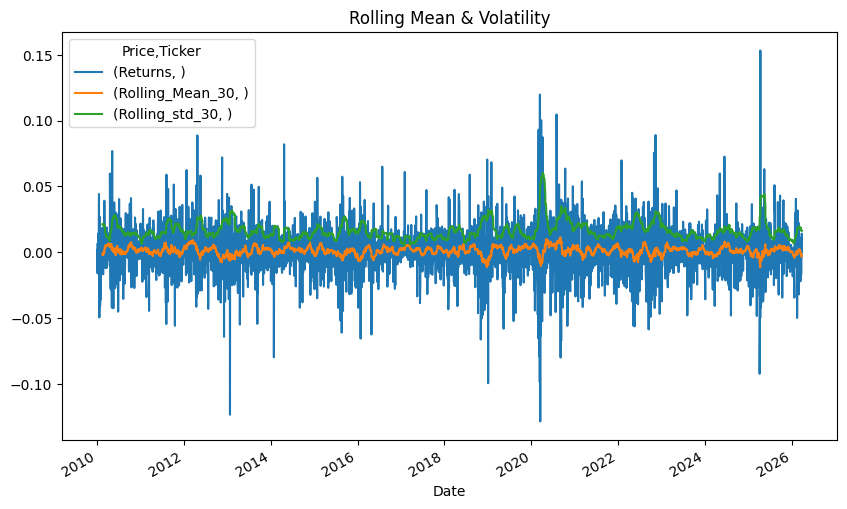

In [30]:
df[['Returns','Rolling_Mean_30', 'Rolling_std_30']].plot(figsize=(10, 6))
plt.title('Rolling Mean & Volatility')
plt.show()


---

# 🤖 6. Model Building (ARIMA)


In [31]:
train_size = int(len(df) * 0.8)
train, test = df['Returns'][:train_size], df['Returns'][train_size:]
model = ARIMA(train, order=(1, 0, 1))
model_fit = model.fit()
predictions = model_fit.forecast(steps =  len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p


---

## 📊 Evaluate

In [32]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test, predictions)
print('Test MSE:', mse)


Test MSE: 0.0002617940316477177


---

# ⚠️ 7. Detecting Model Decay

## 🔹 Concept

Model decay = performance degradation over time

---

## 📉 Track Error Over Time

<Axes: >

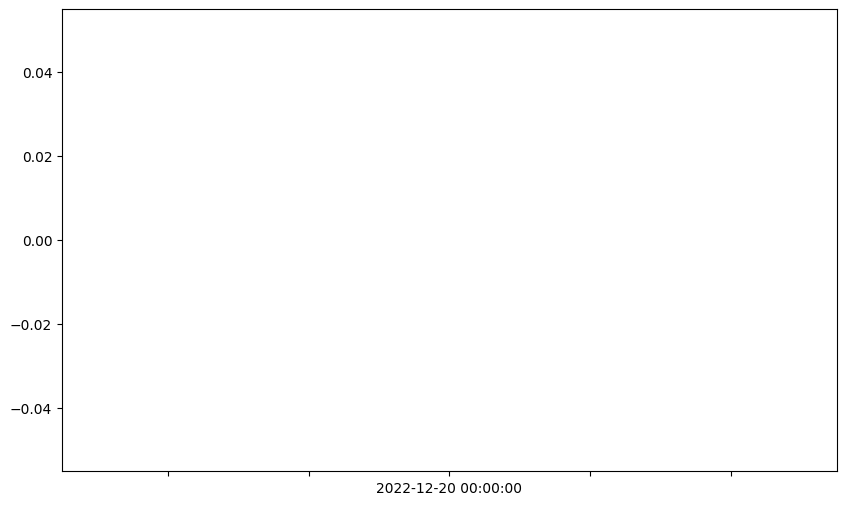

In [33]:
error = test - predictions
error.plot(figsize=(10, 6))

---

## 🔍 Rolling Error

<Axes: >

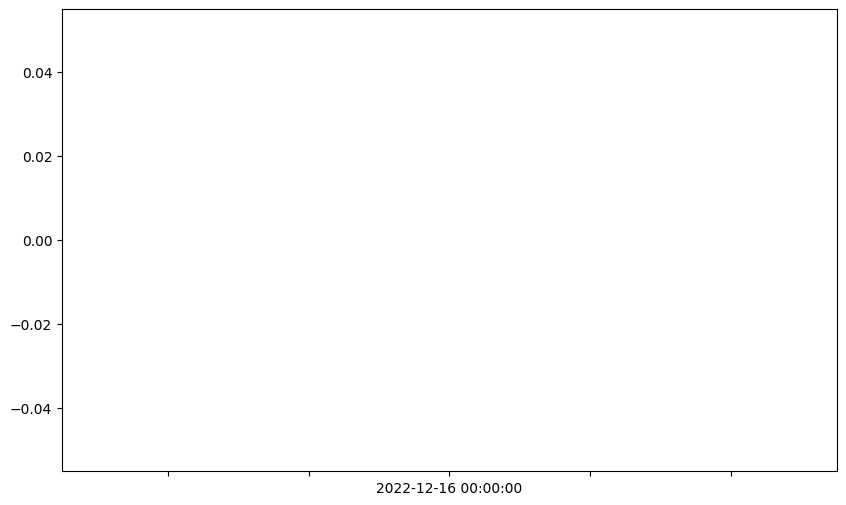

In [ ]:
rolling_error = error.rolling(window=12).mean()
rolling_error.plot(figsize=(10, 6))


---

## 🎯 Insight

* Increasing error = **model decay**
* Indicates need for retraining

---

# 🔁 8. Rolling Retraining

## 🔹 Concept

Instead of training once:
👉 Continuously update model

---

## 🧠 Implementation

In [34]:
history = list(train)
preds= []

for i in range(len(test)):
  model = ARIMA(history, order=(1, 0, 1))
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  preds.append(yhat)
  obs = test[i]
  history.append(obs)


/tmp/ipykernel_183/2158900830.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  obs = test[i]
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmode


---

## 📊 Evaluate Rolling Model

In [ ]:
preds

[np.float64(0.003497140157878698),
 np.float64(0.0019606010571603535),
 np.float64(0.0019159762618430657),
 np.float64(0.0011770032460852256),
 np.float64(3.582699867876564e-06),
 np.float64(0.002254780039345026),
 np.float64(0.0013097985959587336),
 np.float64(0.0018046240478657087),
 np.float64(0.0025994469260161297),
 np.float64(-0.00020131784992777628),
 np.float64(0.000966383058523953),
 np.float64(0.002928448391994531),
 np.float64(0.0007360530910265237),
 np.float64(0.0016176545836551585),
 np.float64(-0.00066584078249013),
 np.float64(0.0008510822963196549),
 np.float64(0.0009016899719007206),
 np.float64(9.176780086363754e-05)]

In [ ]:
rolling_mse = mean_squared_error(test[:18], preds)
print('Rolling MSE:', rolling_mse)

Rolling MSE: 0.0003915404259327192


---

# 📈 Final Visualization

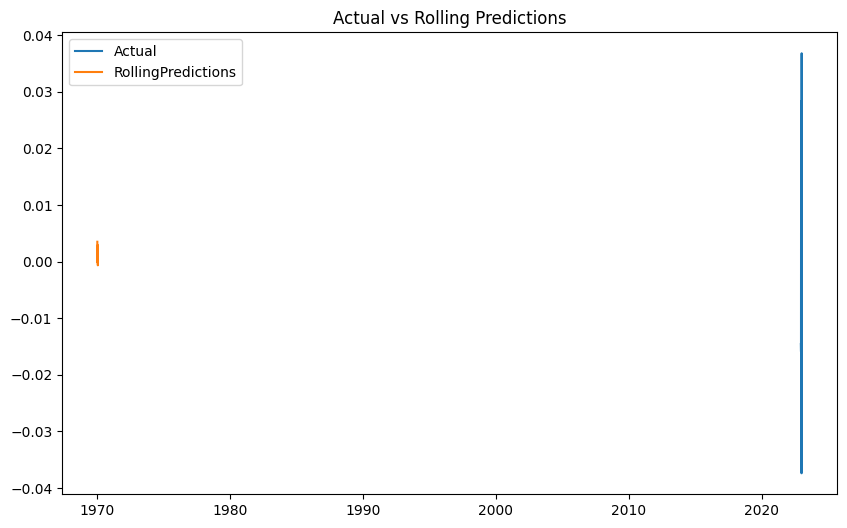

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, preds, label='RollingPredictions')
plt.legend()
plt.title('Actual vs Rolling Predictions')
plt.show()





---

# 🧠 Key Observations (VERY IMPORTANT FOR INTERVIEWS)

### 📌 Stationarity

* Raw prices ❌ non-stationary
* Returns ✅ stationary

---

### 📌 ACF/PACF

* Help select ARIMA parameters
* Prevent overfitting

---

### 📌 Regime Changes

* Volatility clusters exist
* Models fail if regime shifts

---

### 📌 Rolling Statistics

* Reveal structural breaks
* Essential for real-world data

---

### 📌 Model Decay

* Static models degrade
* Financial markets are dynamic

---

### 📌 Rolling Retraining

* Adaptive models perform better
* Industry-standard approach

---

# 🏁 Final Output

You now have a **production-grade pipeline** that:

✅ Handles non-stationarity
✅ Detects regimes
✅ Uses ACF/PACF intelligently
✅ Detects model decay
✅ Retrains dynamically

---